# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
from tqdm.auto import tqdm
import spacy


from IPython.display import display # para mostrar o dataset de forma mais legível
from sklearn.dummy import DummyClassifier # para criar um modelo de baseline que sempre chuta a classe mais frequente
from sklearn.feature_extraction.text import TfidfVectorizer # para transformar os textos em números
from sklearn.linear_model import LogisticRegression # para criar um modelo de regressão logística

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

/home/angelaferrari/miniconda3/envs/sprint_14/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

sns.set_style()

In [3]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [4]:
df_reviews = pd.read_csv('imdb_reviews.zip', sep='\t', dtype={'votes': 'Int64'})

#  📖 Campos a serem explorados: 

    
| Coluna (no arquivo) | O que representa |
|---|---|
| review | O texto da resenha. |
|pos|**Alvo**: o objetivo (sentimento), '0' para negativo e '1' para positivo - |
|ds_part|'train'/'test' para a parte de treinamento/teste do conjunto de dados, respectivamente |  

In [5]:
display(df_reviews.head())

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [6]:
df_reviews['review'].isnull().sum()

np.int64(0)

In [7]:
df_reviews.duplicated(subset=['review']).sum()

np.int64(91)

In [8]:
# analisando os tipos das colunas que interessam para o nosso projeto, ou seja, 'review' e 'pos'
df_reviews[['review', 'pos']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  47331 non-null  object
 1   pos     47331 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 739.7+ KB


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

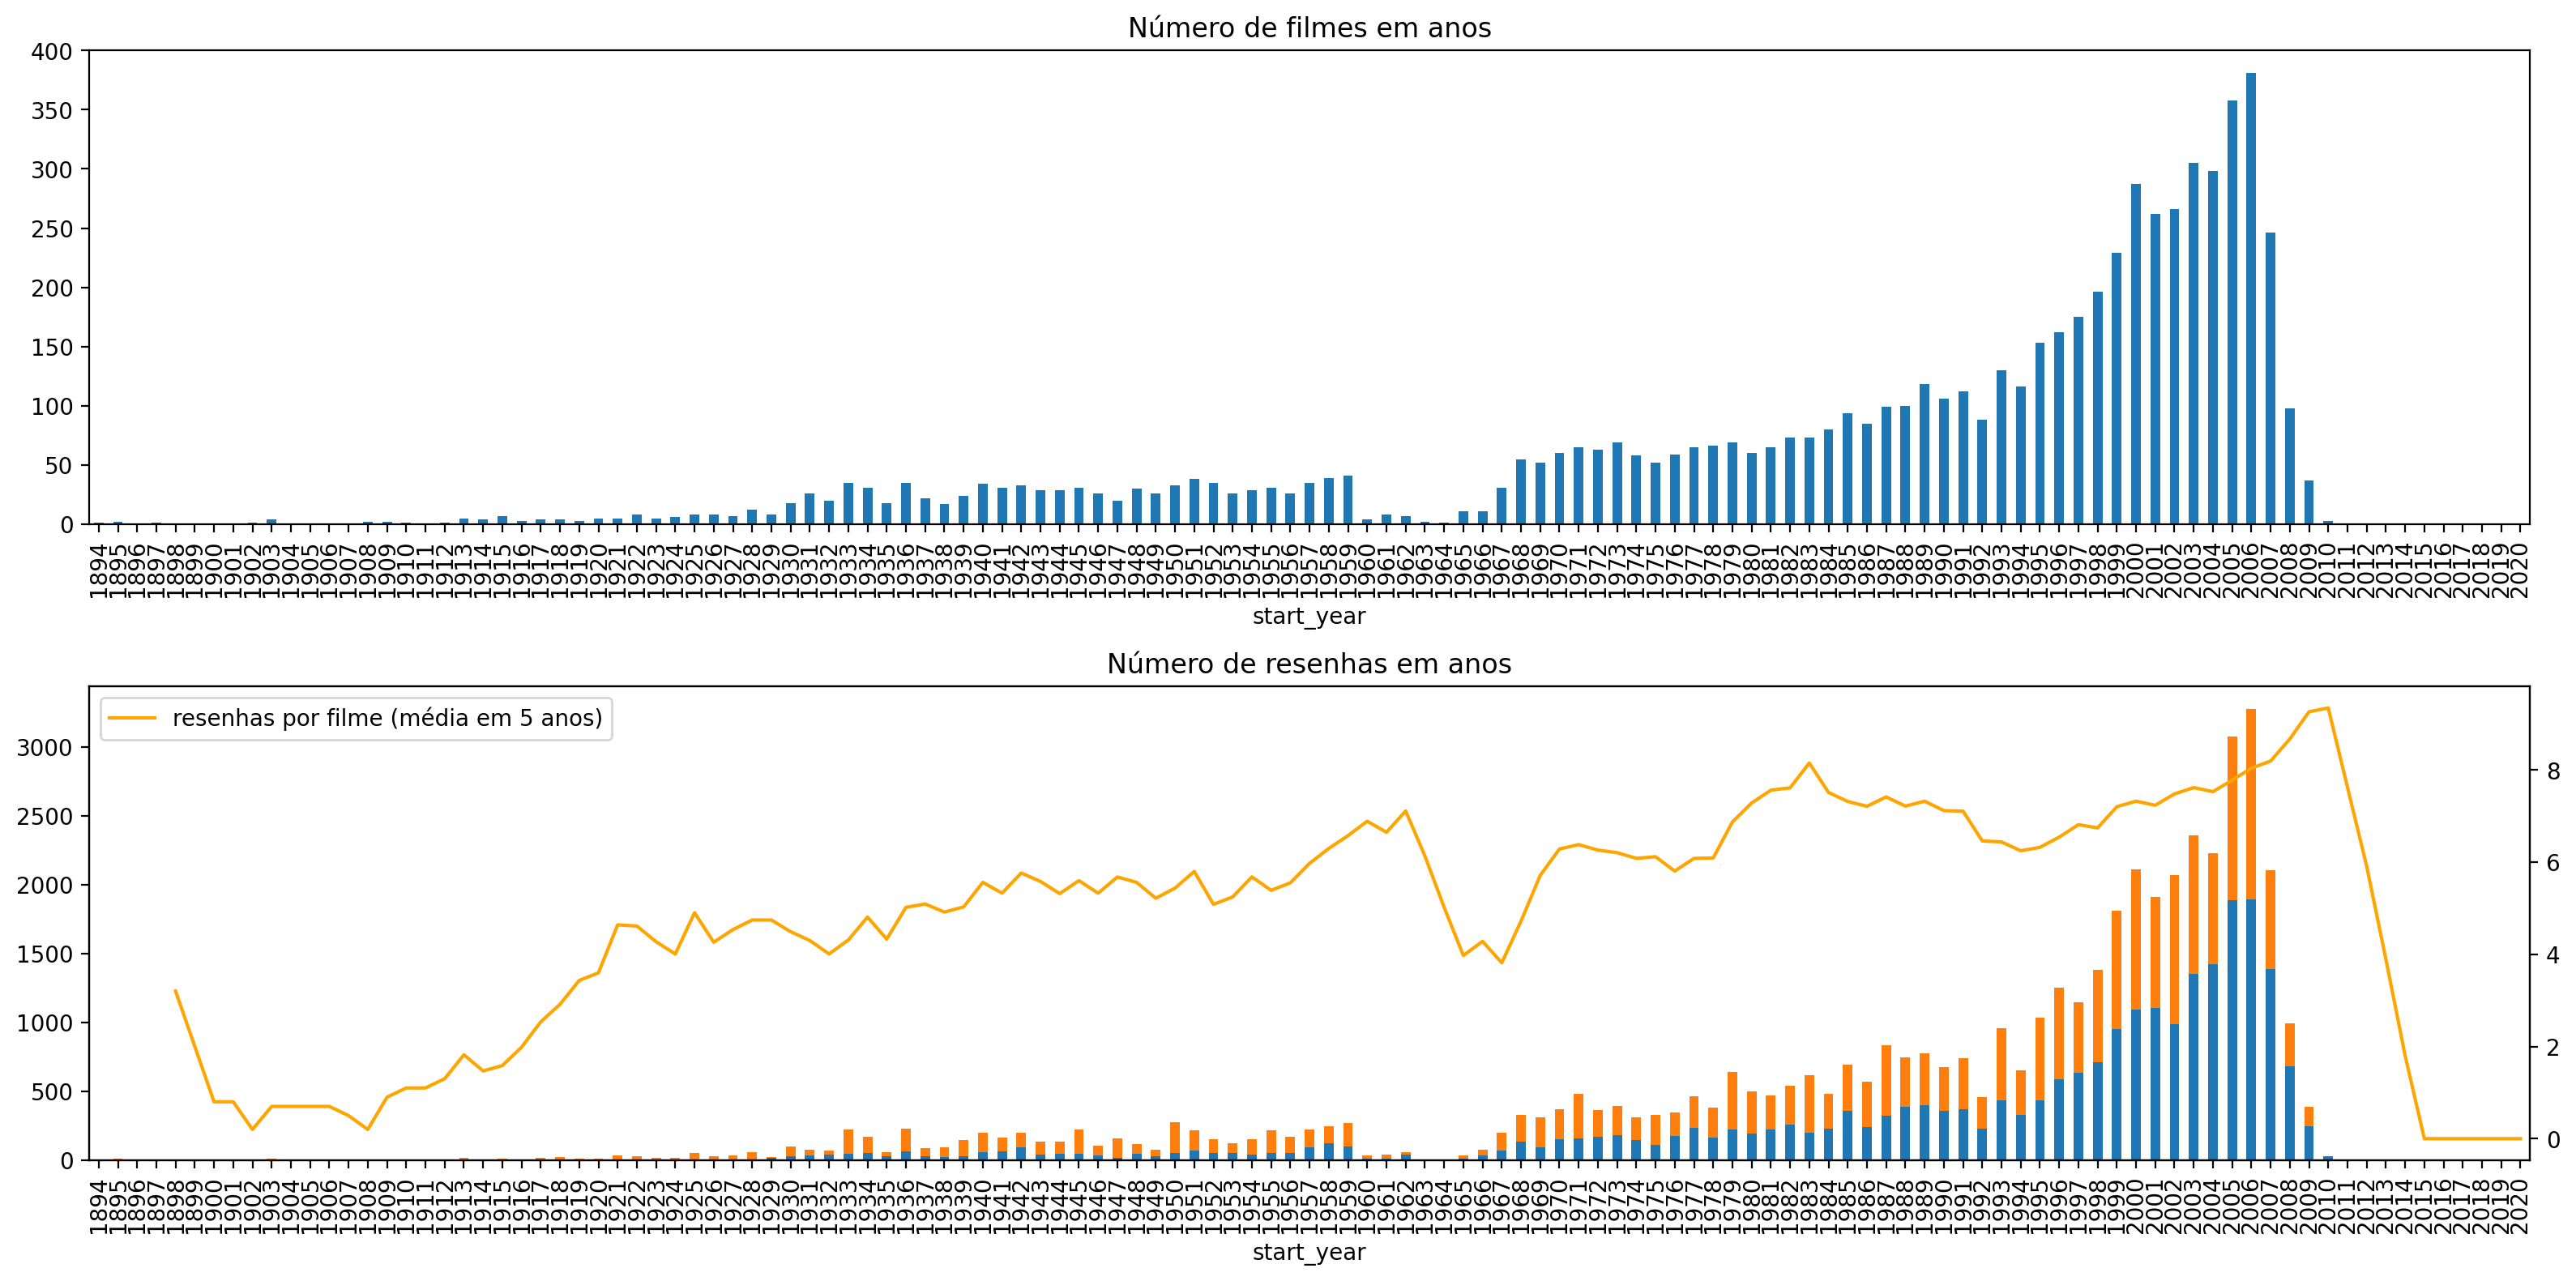

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

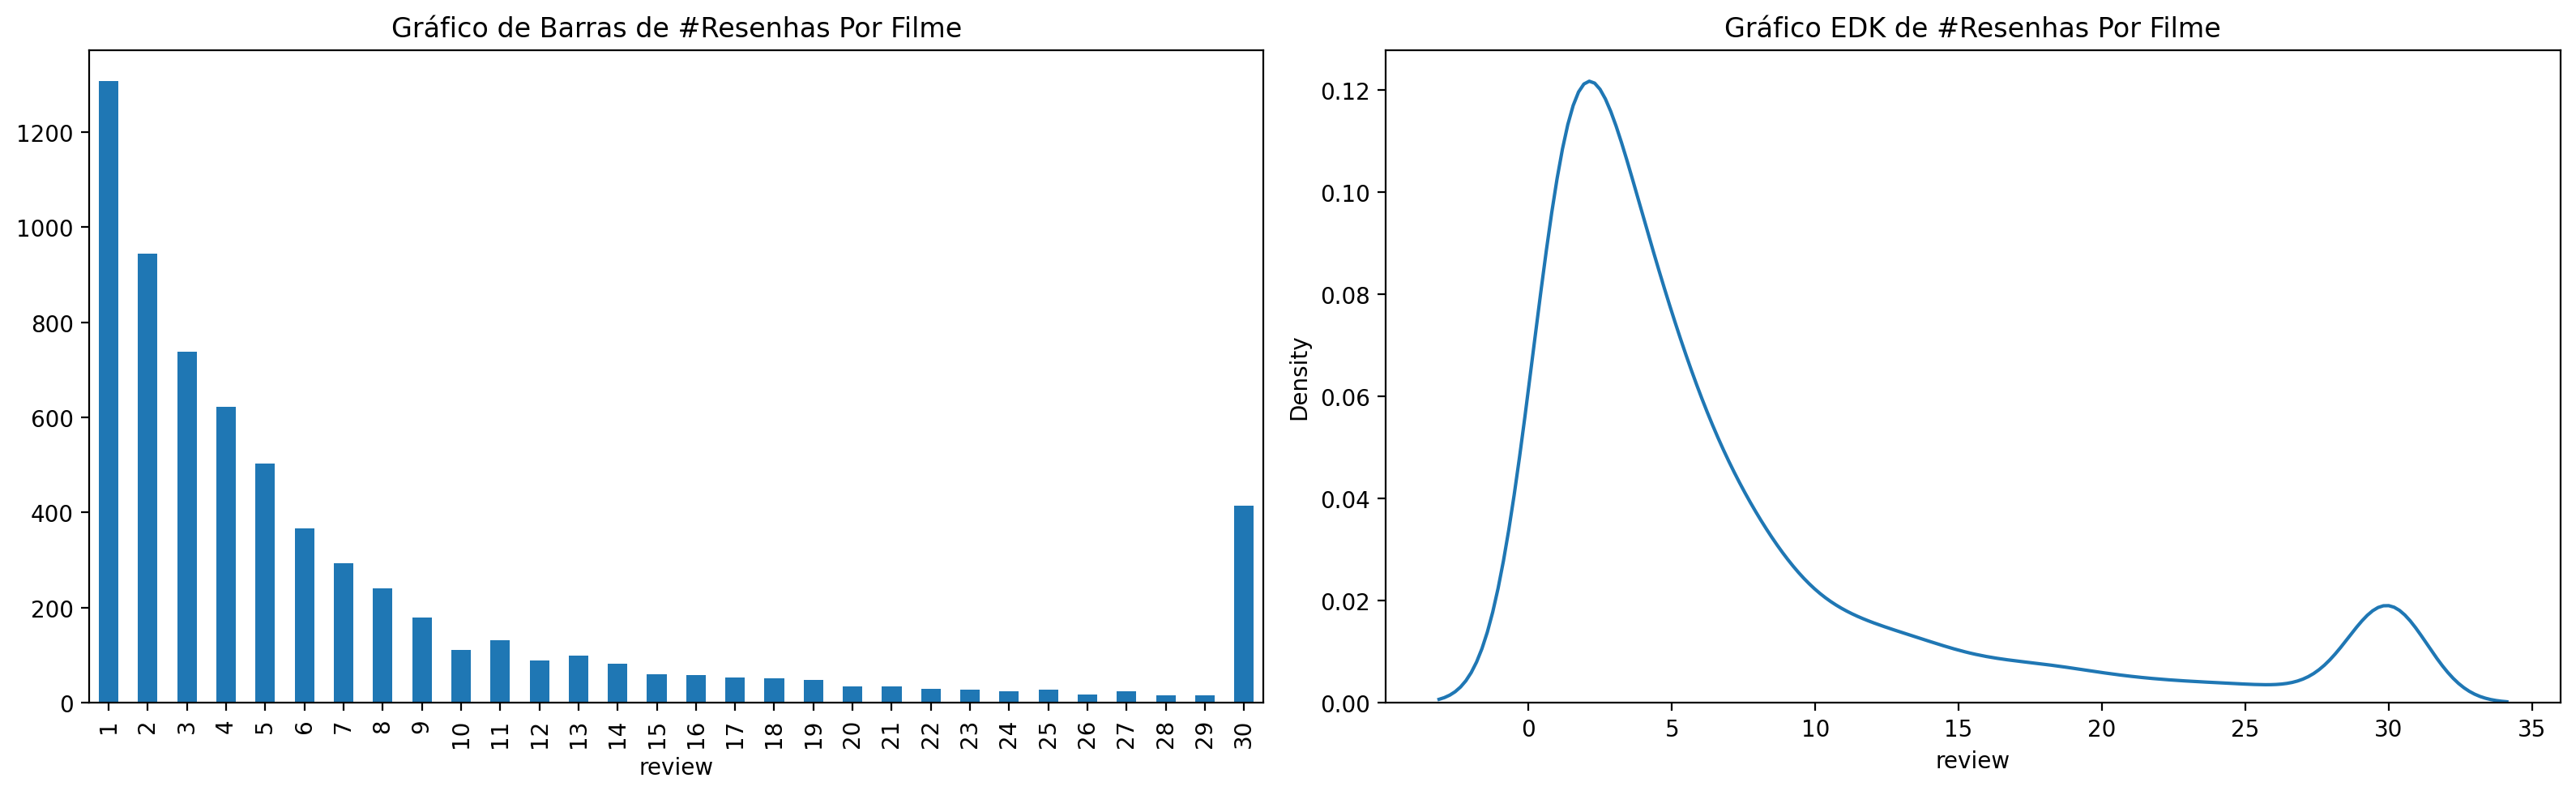

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

Vamos verificar o Equilibrio das classes

In [11]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

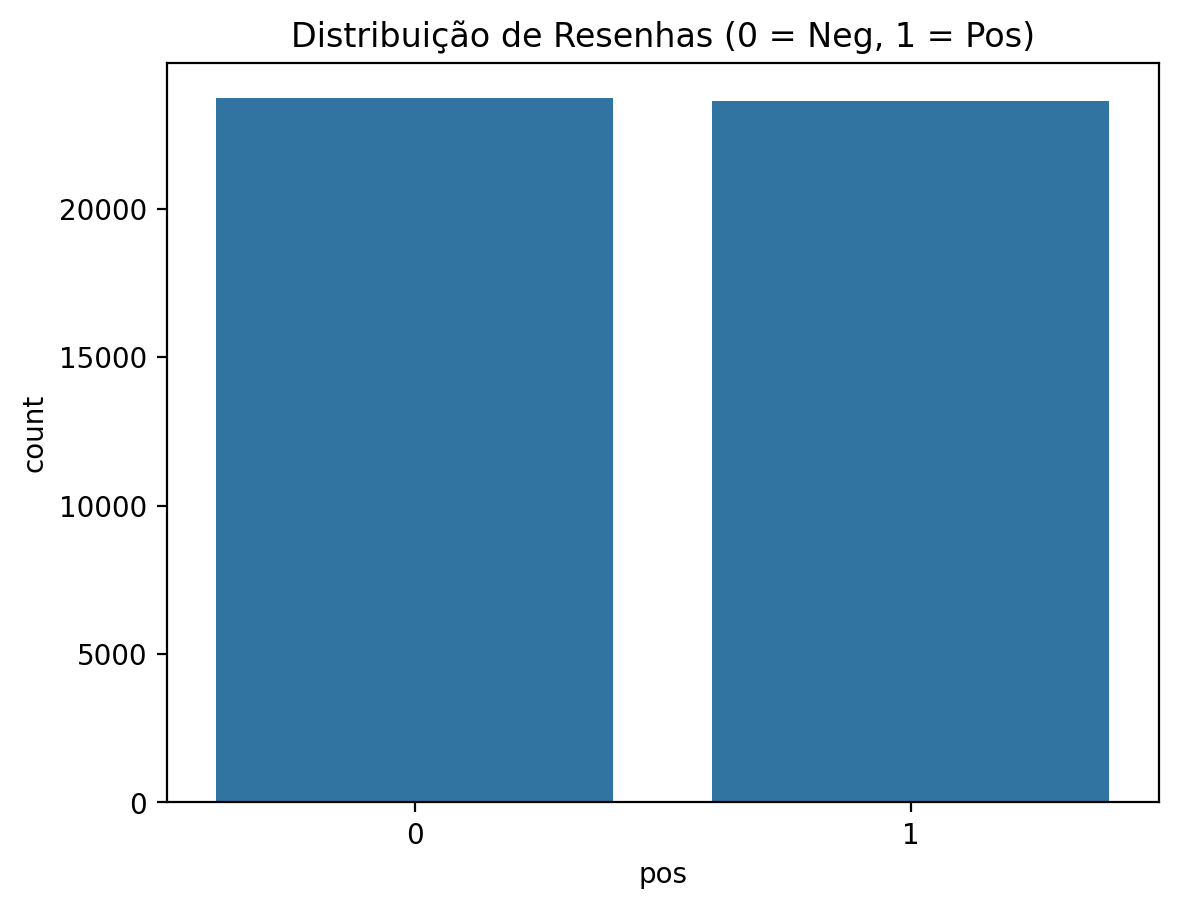

In [12]:
sns.countplot(x='pos', data=df_reviews)
plt.title('Distribuição de Resenhas (0 = Neg, 1 = Pos)')
plt.show()

Os dados estão extremamente equilibrados, praticamente 50% para casa opinião, tornando a métrica F1 Score mais confiável

Vamos analisar a distribuição da classificação nos consjuntos de treino e teste.

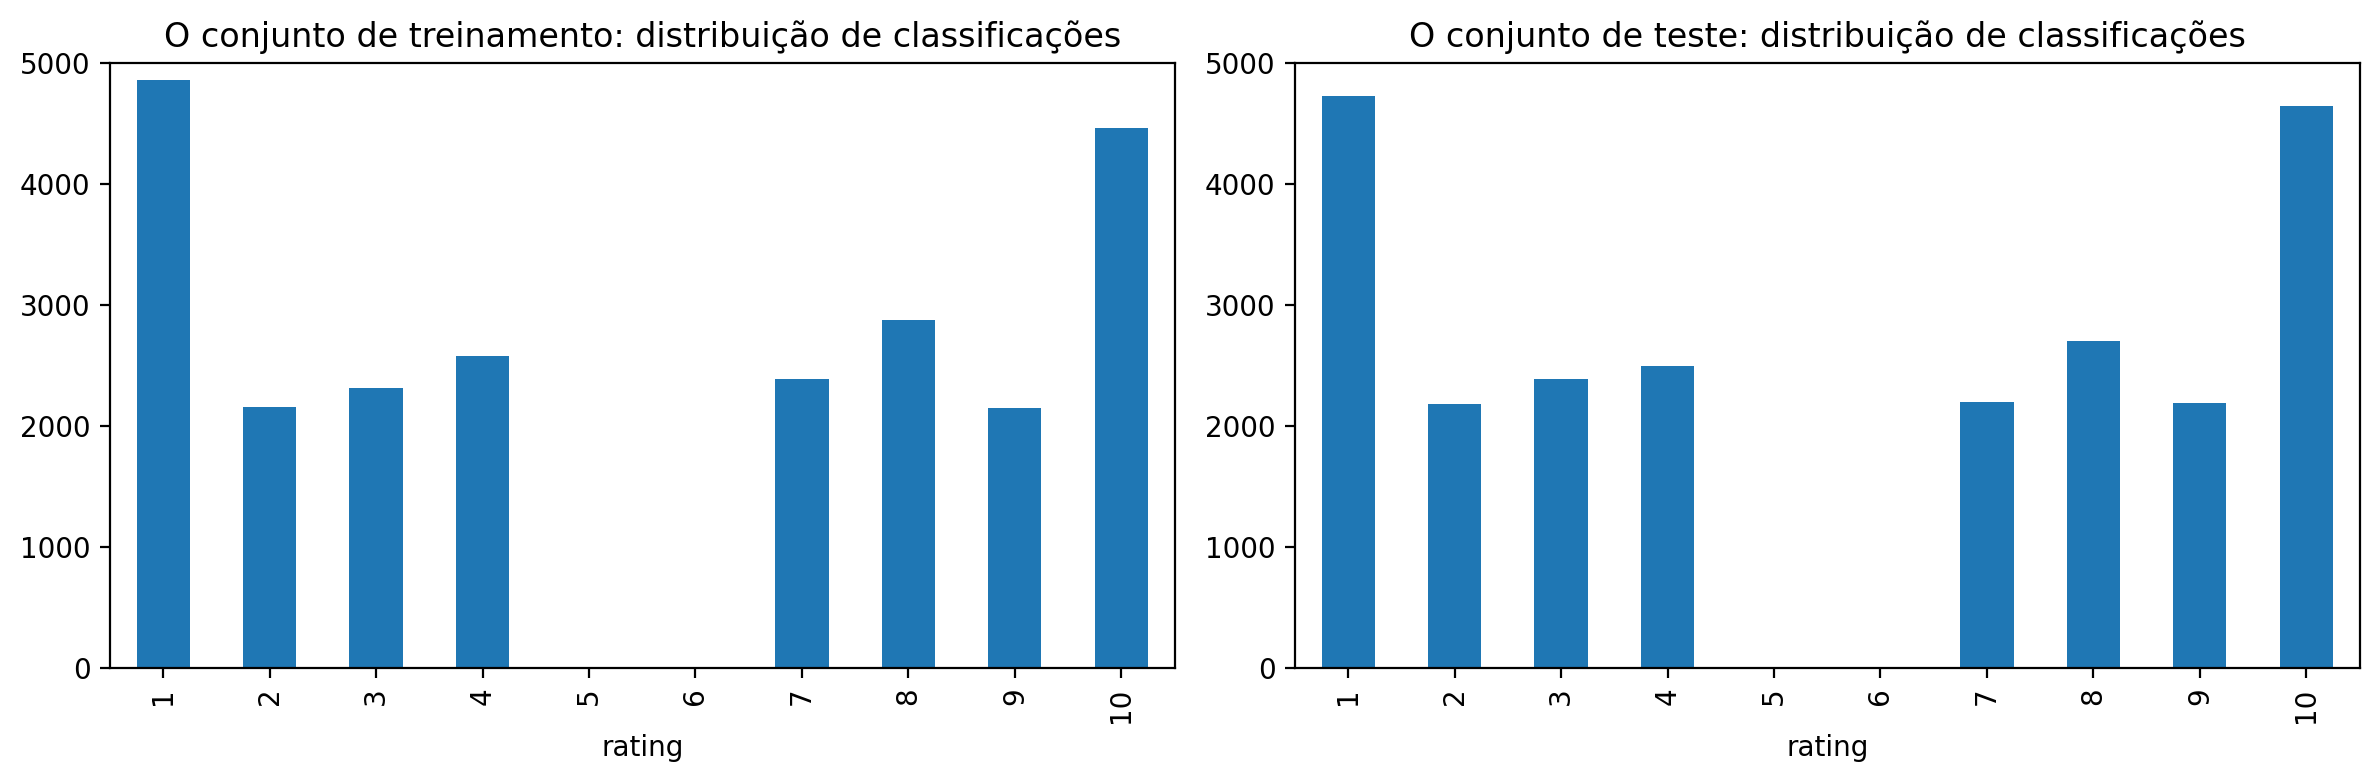

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/tmp/ipykernel_14243/1483671763.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_14243/1483671763.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/tmp/ipykernel_14243/1483671763.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_14243/1483671763.py:31: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please updat

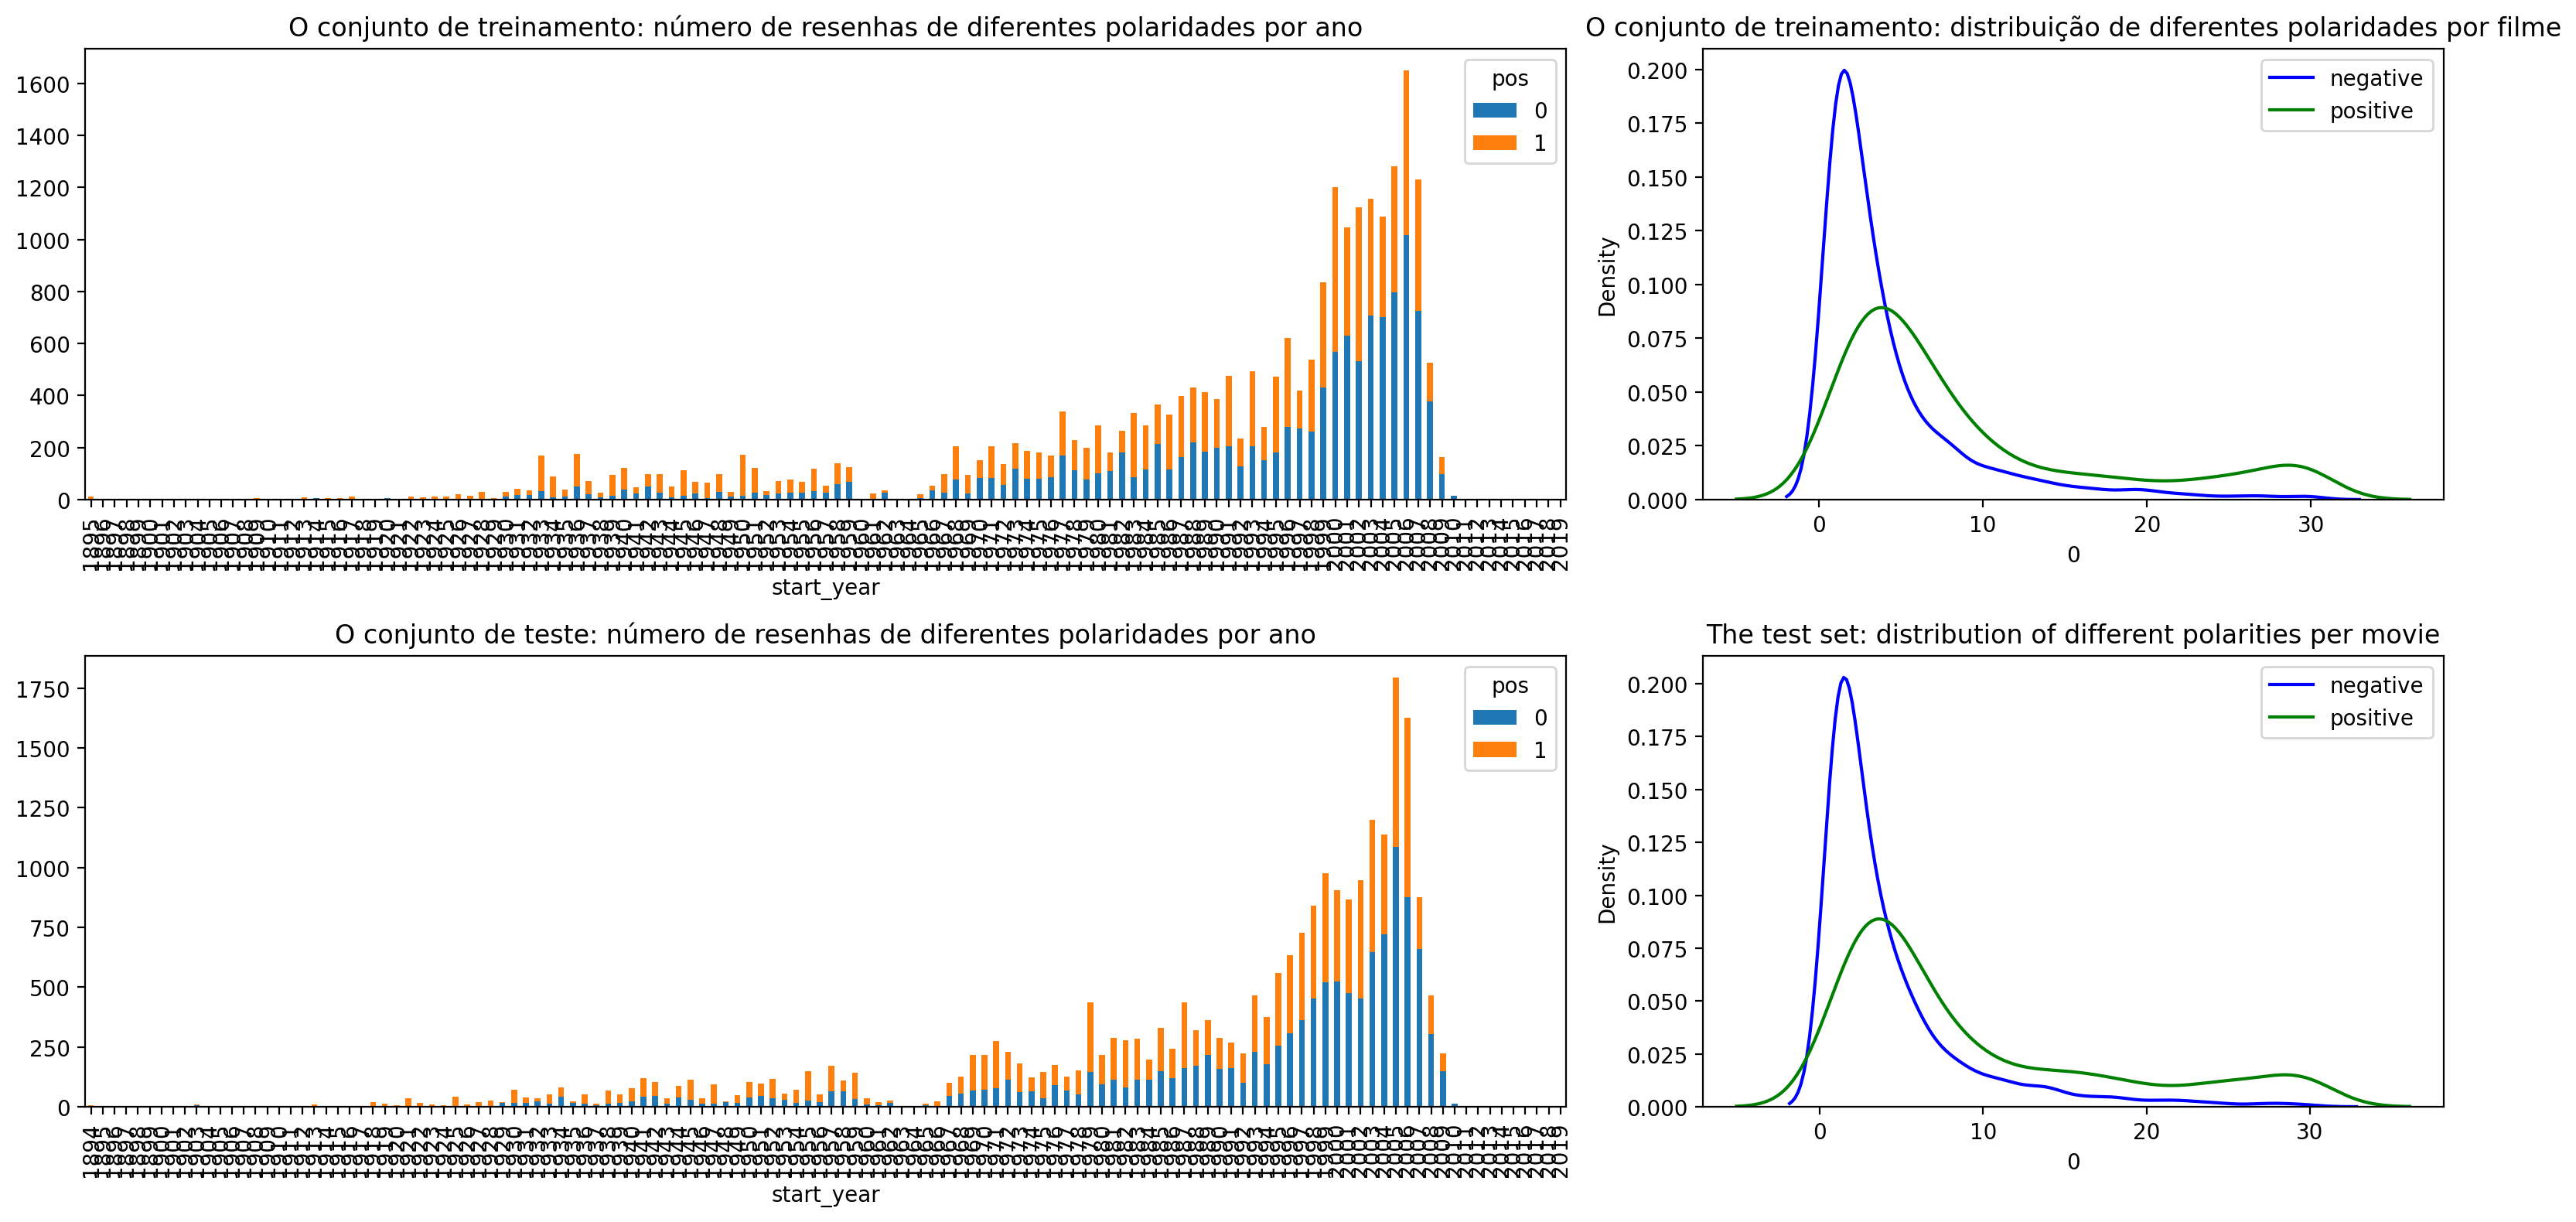

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [15]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        max_f1_score_idx = np.argmax(f1_scores)
        best_f1 = f1_scores[max_f1_score_idx]
        eval_stats[type]['F1'] = best_f1

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Acurácia'] = metrics.accuracy_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    

    return
    

# Pré Processamento 

- Tokenização
- Normalização
- Redução de Palavras

A condução do projeto me leva a entender que analisaremos de forma didatica um encremento de cada uma dessas etapas, e possivelmente o melhor desempenho da metrica.

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [16]:
def normalize_text(text):
    # 1. Converte para minúsculas
    text = text.lower()
    # 2. Remove tudo que NÃO for letra (substitui por espaço)
    # O padrão '[^a-zA-Z]' significa: mantenha apenas letras de A a Z
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Remove espaços extras que sobraram
    text = " ".join(text.split())
    return text

In [17]:
df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [18]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [19]:
# 1. Inicializamos o 'tradutor' de palavras para números
# Usamos stop_words='english' para o modelo ignorar palavras inúteis
vectorizer = TfidfVectorizer(stop_words='english')

# 2. Criamos as Features de Treino e Teste
# O fit_transform aprende o vocabulário e transforma o texto em números
train_features_0 = vectorizer.fit_transform(df_reviews_train['review_norm'])

# 3. Criamos as Features de Teste
# Usamos apenas transform para que o teste seja traduzido com o vocabulário do treino
test_features_0 = vectorizer.transform(df_reviews_test['review_norm'])

# imprimindo as formas das matrizes de features para verificar se estão corretas
print(train_features_0.shape)
print(test_features_0.shape)

(23796, 71365)
(23535, 71365)


          train  test
Acurácia   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50


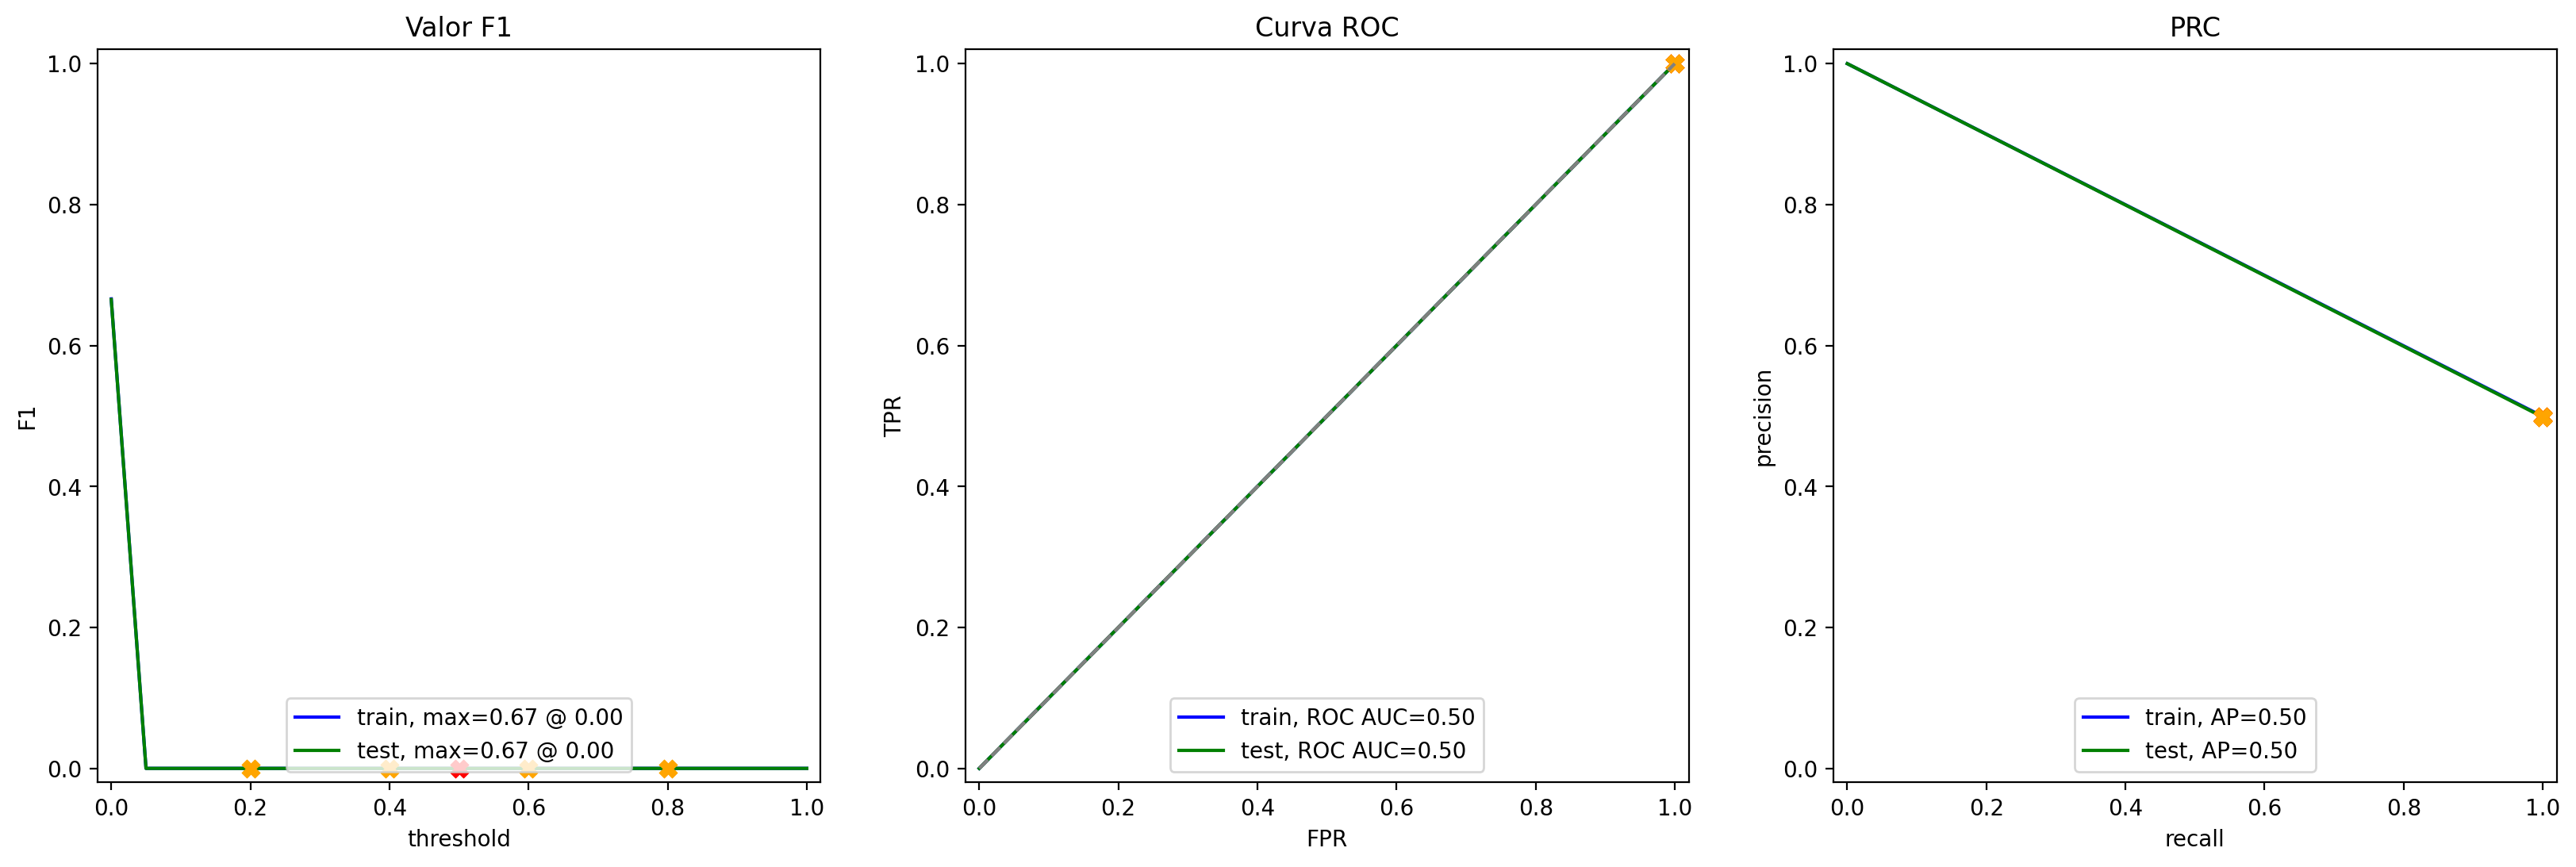

In [ ]:
# Criar o modelo que sempre chuta a classe mais frequente
dummy_model = DummyClassifier(strategy='most_frequent')

# Treinar (ele apenas conta qual classe aparece mais) 
dummy_model.fit(train_features_0, train_target)

# Avaliar usando a função que o projeto te deu
evaluate_model(dummy_model, train_features_0, train_target, test_features_0, test_target)

### Modelo 1 - NLTK, TF-IDF e Regressão Logistica

NLTK : é uma biblioteca Python usada para ensinar e aplicar técnicas básicas de processamento de linguagem natural, como tokenização, limpeza e análise de texto.


TF - IDF : Ele dá um peso maior para palavras raras e importantes e um peso menor para palavras que aparecem em quase todas as resenhas

In [21]:
import nltk  

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords # Uma lista de palavras gramaticais que aparecem muito, mas não têm "sentimento" (ex: the, is, at, on, by).

Essas bibliotecas importadas acima, me sugerem que eu analise este modelo limpando as palavras inuteis, sem necessariamente fazer a etapa de Lematização.

O NLTK só consegue identificar se uma palavra é "stopwords" se o texto já estiver quebrado em uma lista de palavras individuais.

Nota: O TfidfVectorizer,  faz isso internamente, mas quando usamos o NLTK, geralmente fazemos manualmente primeiro para limpar as palavras. (nltk.word_tokenize(text))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/angelaferrari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


          train  test
Acurácia   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


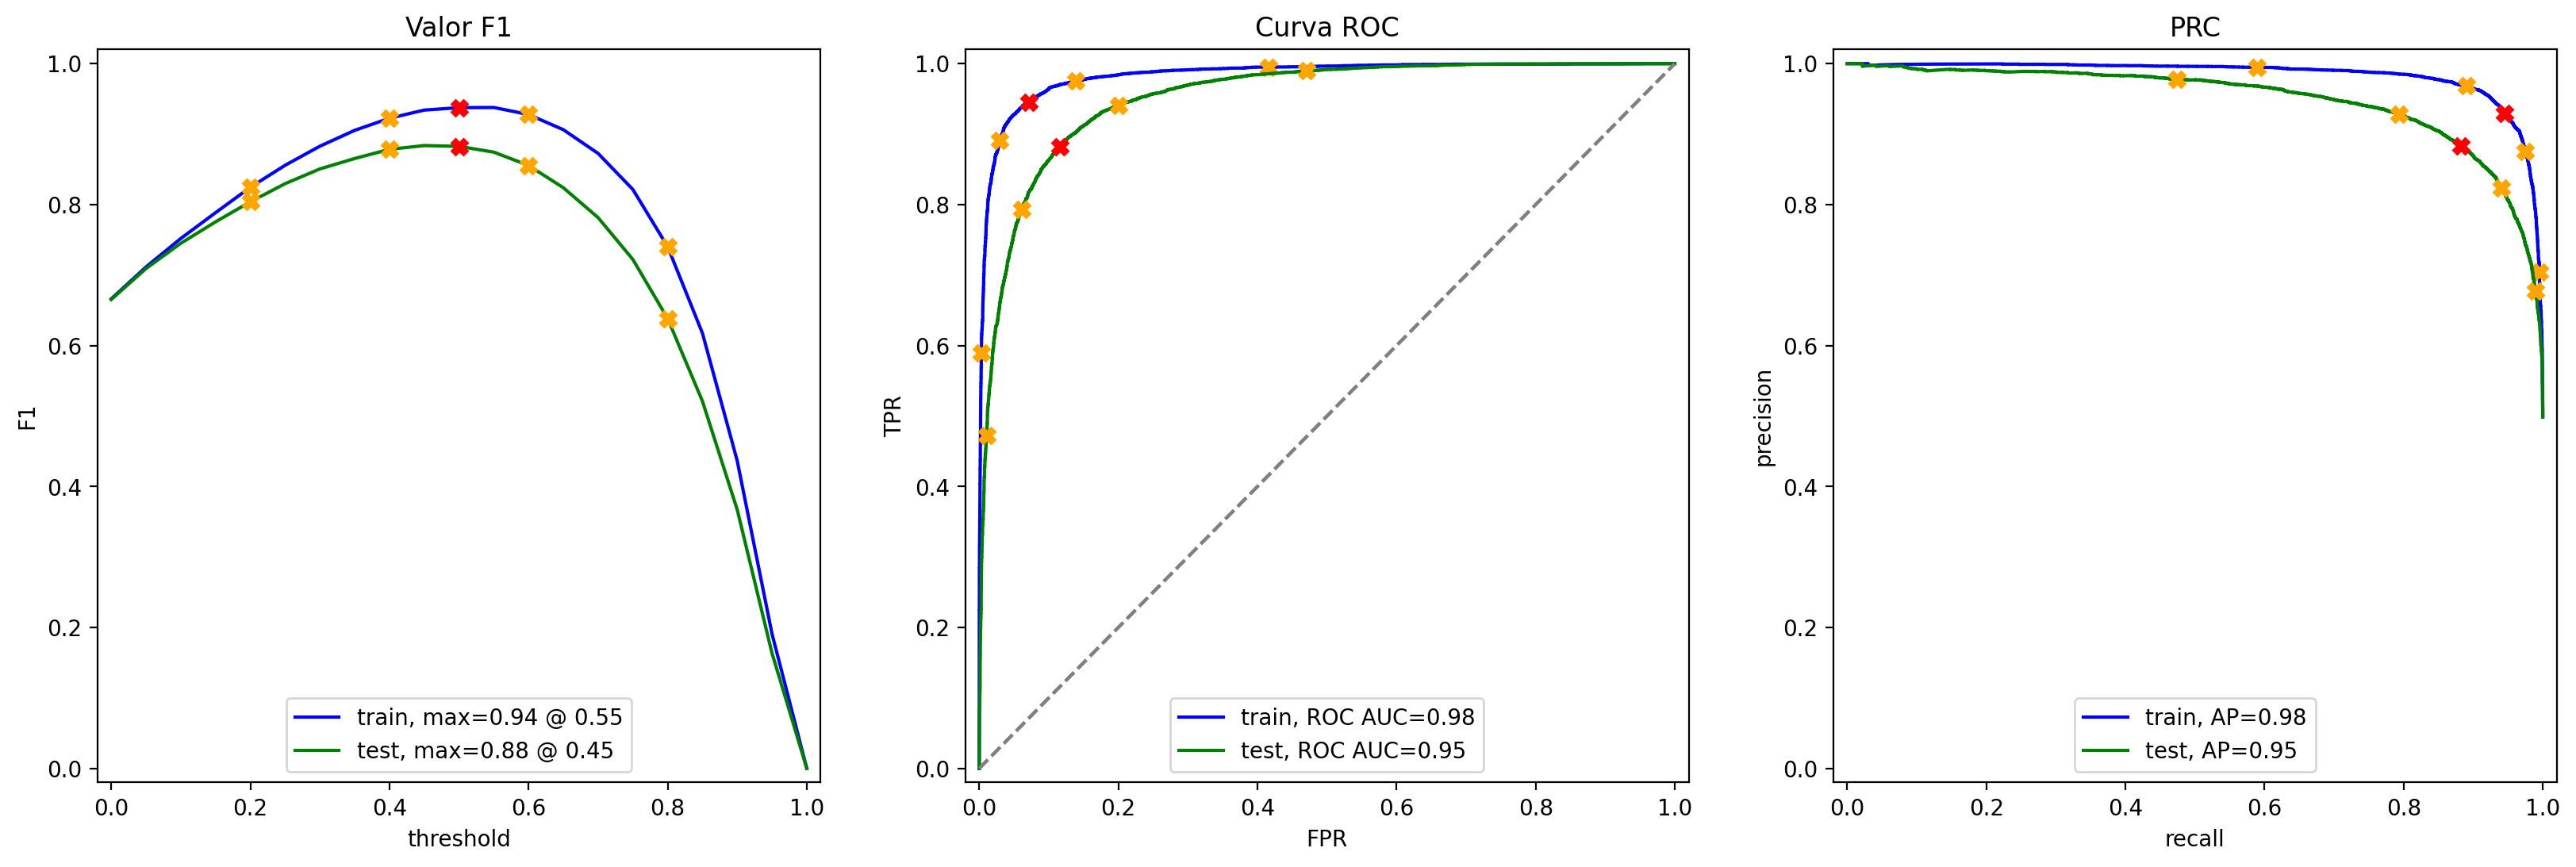

In [41]:
# 1. Garante que as palavras inúteis estão baixadas
nltk.download('stopwords')
stop_words = list(stopwords.words('english'))

# 2. Na hora de criar o vetorizador, você "alimenta" ele com essa lista
vectorizer_1 = TfidfVectorizer(stop_words=stop_words)

# 3. Transforma seu texto normalizado em números
train_features_1 = vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = vectorizer_1.transform(df_reviews_test['review_norm'])

# 4. Treina a Regressão Logística
model_1 = LogisticRegression(solver='liblinear')
model_1.fit(train_features_1, train_target)

# 5. Avaliar usando a função do projeto
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 2 - spaCy, TF-IDF e Regressão Logística

In [23]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner']) # Carrega o modelo spaCy para inglês, desabilitando o parser e o NER

In [24]:
def text_preprocessing_2(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    return ' '.join(tokens)

          train  test
Acurácia   0.93  0.87
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


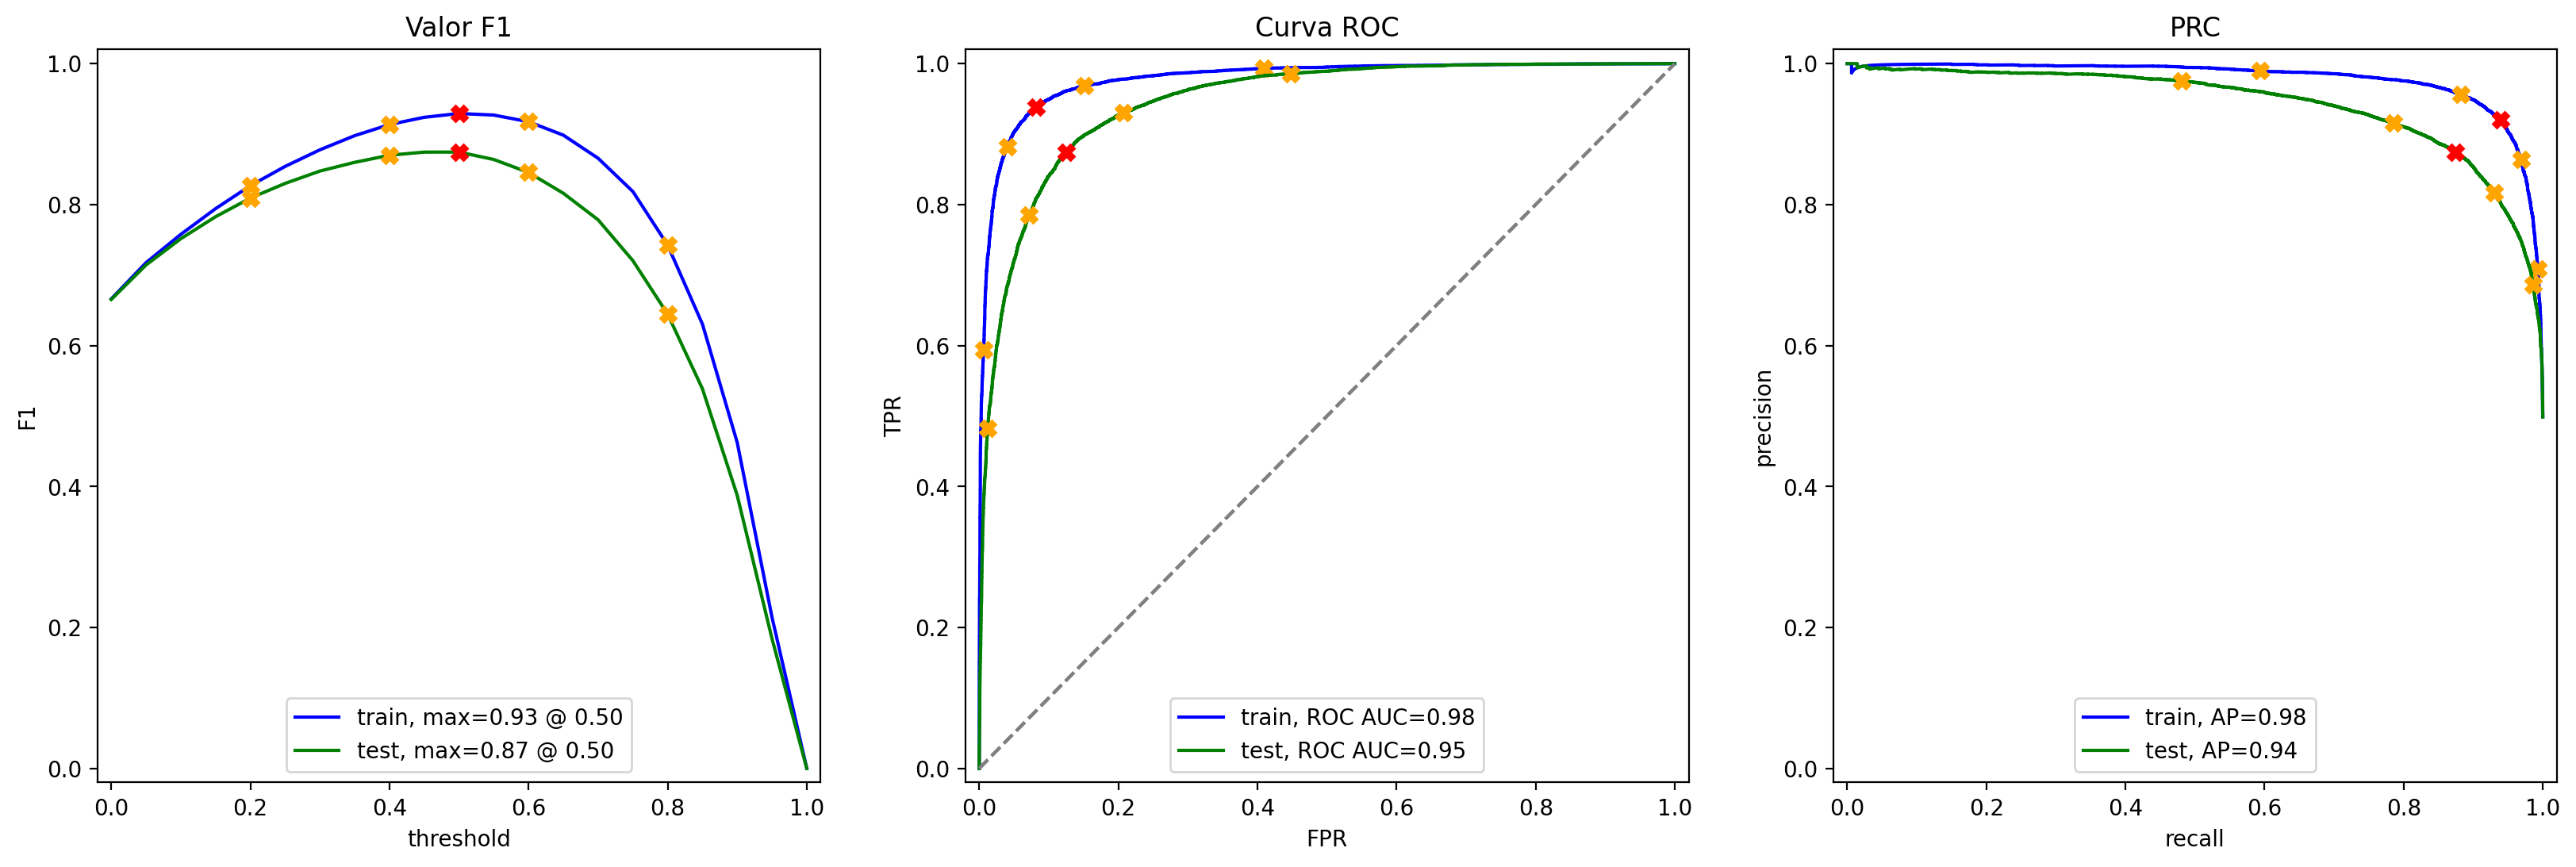

In [25]:
# 1. Criar a coluna lematizada diretamente nos DataFrames de treino/teste
df_reviews_train['review_lemma'] = df_reviews_train['review_norm'].apply(text_preprocessing_2)
df_reviews_test['review_lemma'] = df_reviews_test['review_norm'].apply(text_preprocessing_2)

# 2. Inicializar o vetorizador TF-IDF para o Modelo 2
# Vamos manter o padrão de usar as stop_words do NLTK ou do próprio TF-IDF
vectorizer_2 = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.9)

# 3. Criar as features de Treino e Teste  
train_features_2 = vectorizer_2.fit_transform(df_reviews_train['review_lemma'])
test_features_2 = vectorizer_2.transform(df_reviews_test['review_lemma'])


# 4. Treinar a Regressão Logística (Modelo 2)
model_2 = LogisticRegression(solver='liblinear')
model_2.fit(train_features_2, train_target)

# 5. Avaliar usando a função evaluate_model fornecida pelo projeto
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

### Modelo 3 - SpaCy, TF-IDF e XGBoost

/home/angelaferrari/miniconda3/envs/sprint_14/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:28:44] WARNING: /home/task_177465307475651/croot/xgboost-split_1774653124670/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          train  test
Acurácia   0.92  0.84
F1         0.92  0.85
APS        0.98  0.92
ROC AUC    0.98  0.92


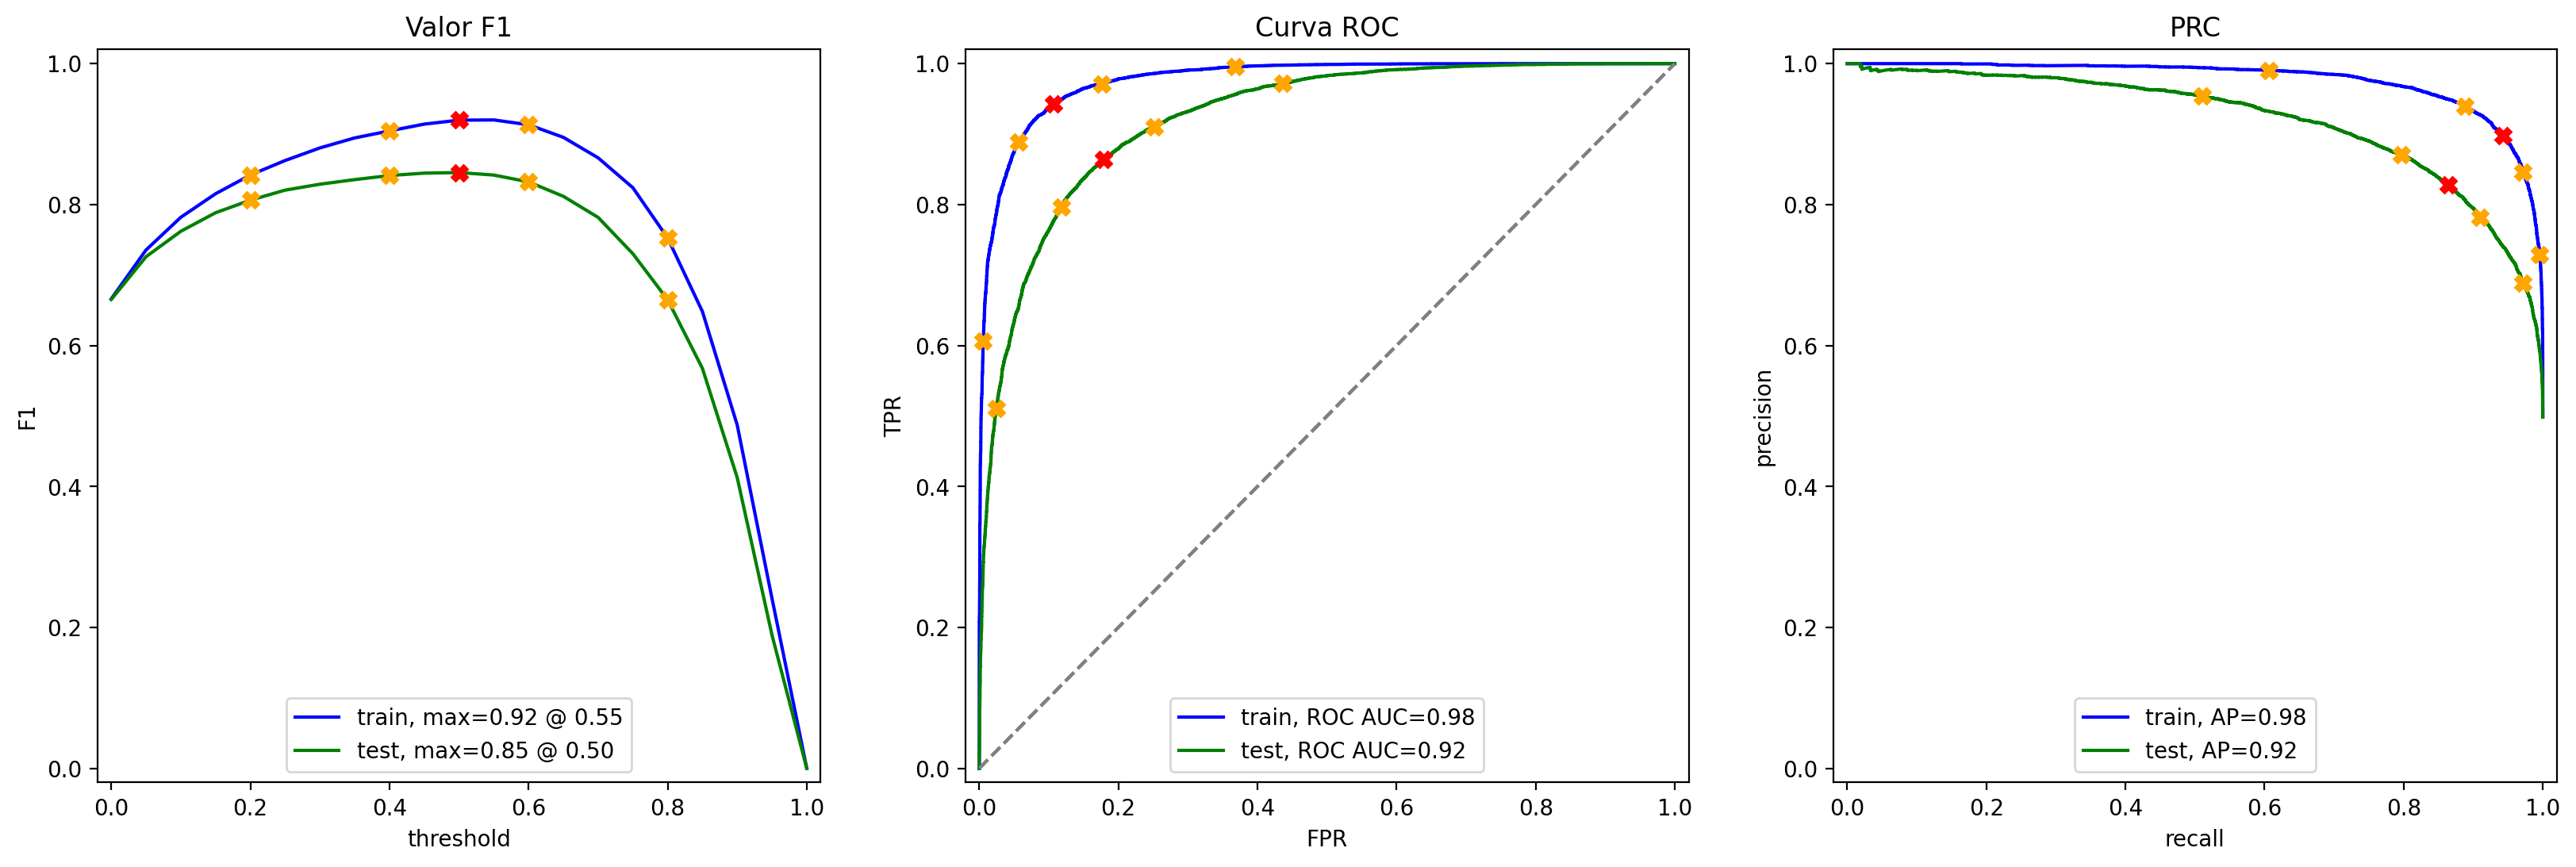

In [ ]:
from xgboost import XGBClassifier

# 1. Reutilizar o texto lematizado (não precisa rodar o spaCy de novo!)
vectorizer_3 = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.9)

train_features_3 = vectorizer_3.fit_transform(df_reviews_train['review_lemma'])
test_features_3 = vectorizer_3.transform(df_reviews_test['review_lemma'])

# 2. Inicializar o XGBoost
# Nota: use n_jobs=-1 para usar todos os núcleos do seu processador e acelerar
model_3 = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.2, 
    max_depth=6, 
    use_label_encoder=False, 
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

# 3. Treinar o modelo
model_3.fit(train_features_3, train_target)

# 4. Avaliar usando sua função padrão
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

###  Modelo 4 - BERT

In [28]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModel
  

In [29]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1481.54it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# Criando uma amostra bem pequena para o BERT
bert_sample_train = df_reviews_train.sample(50, random_state=42)
bert_sample_test = df_reviews_test.sample(25, random_state=42)

# Pegando os alvos (pos) dessas amostras
train_target_4 = bert_sample_train['pos']
test_target_4 = bert_sample_test['pos']

In [32]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    for text in texts:
        encoded = tokenizer(
            text,
            add_special_tokens=True,
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True
        )
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])
    
    # Lógica de seleção do dispositivo
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes
    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
        # Seleção do lote (slice) para IDs
        ids_batch = torch.LongTensor(ids_list[batch_size*i : batch_size*(i+1)]).to(device)
        
        # Seleção do lote (slice) para a máscara de atenção
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i : batch_size*(i+1)]).to(device)
            
        with torch.no_grad():            
            model.eval()
            # Passagem do batch pelo modelo
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
            
        # Extração do CLS token (primeiro token) e conversão para numpy
        # [:, 0, :] pega a primeira posição de cada sequência no lote
        embeddings.append(batch_embeddings[0][:, 0, :].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [34]:
# Ajuste para rodar na CPU do seu notebook
train_features_4 = BERT_text_to_embeddings(bert_sample_train['review_norm'], force_device='cpu')
test_features_4 = BERT_text_to_embeddings(bert_sample_test['review_norm'], force_device='cpu')

Usando o dispositivo cpu.


100%|██████████| 1/1 [00:32<00:00, 32.90s/it]


Usando o dispositivo cpu.


100%|██████████| 1/1 [00:16<00:00, 16.04s/it]


In [37]:
print(bert_sample_train['review_norm'].shape)
print(train_features_4.shape)
print(train_target_4.shape)

(50,)
(50, 768)
(50,)


          train  test
Acurácia    1.0  0.72
F1          1.0  0.67
APS         1.0  0.69
ROC AUC     1.0  0.74


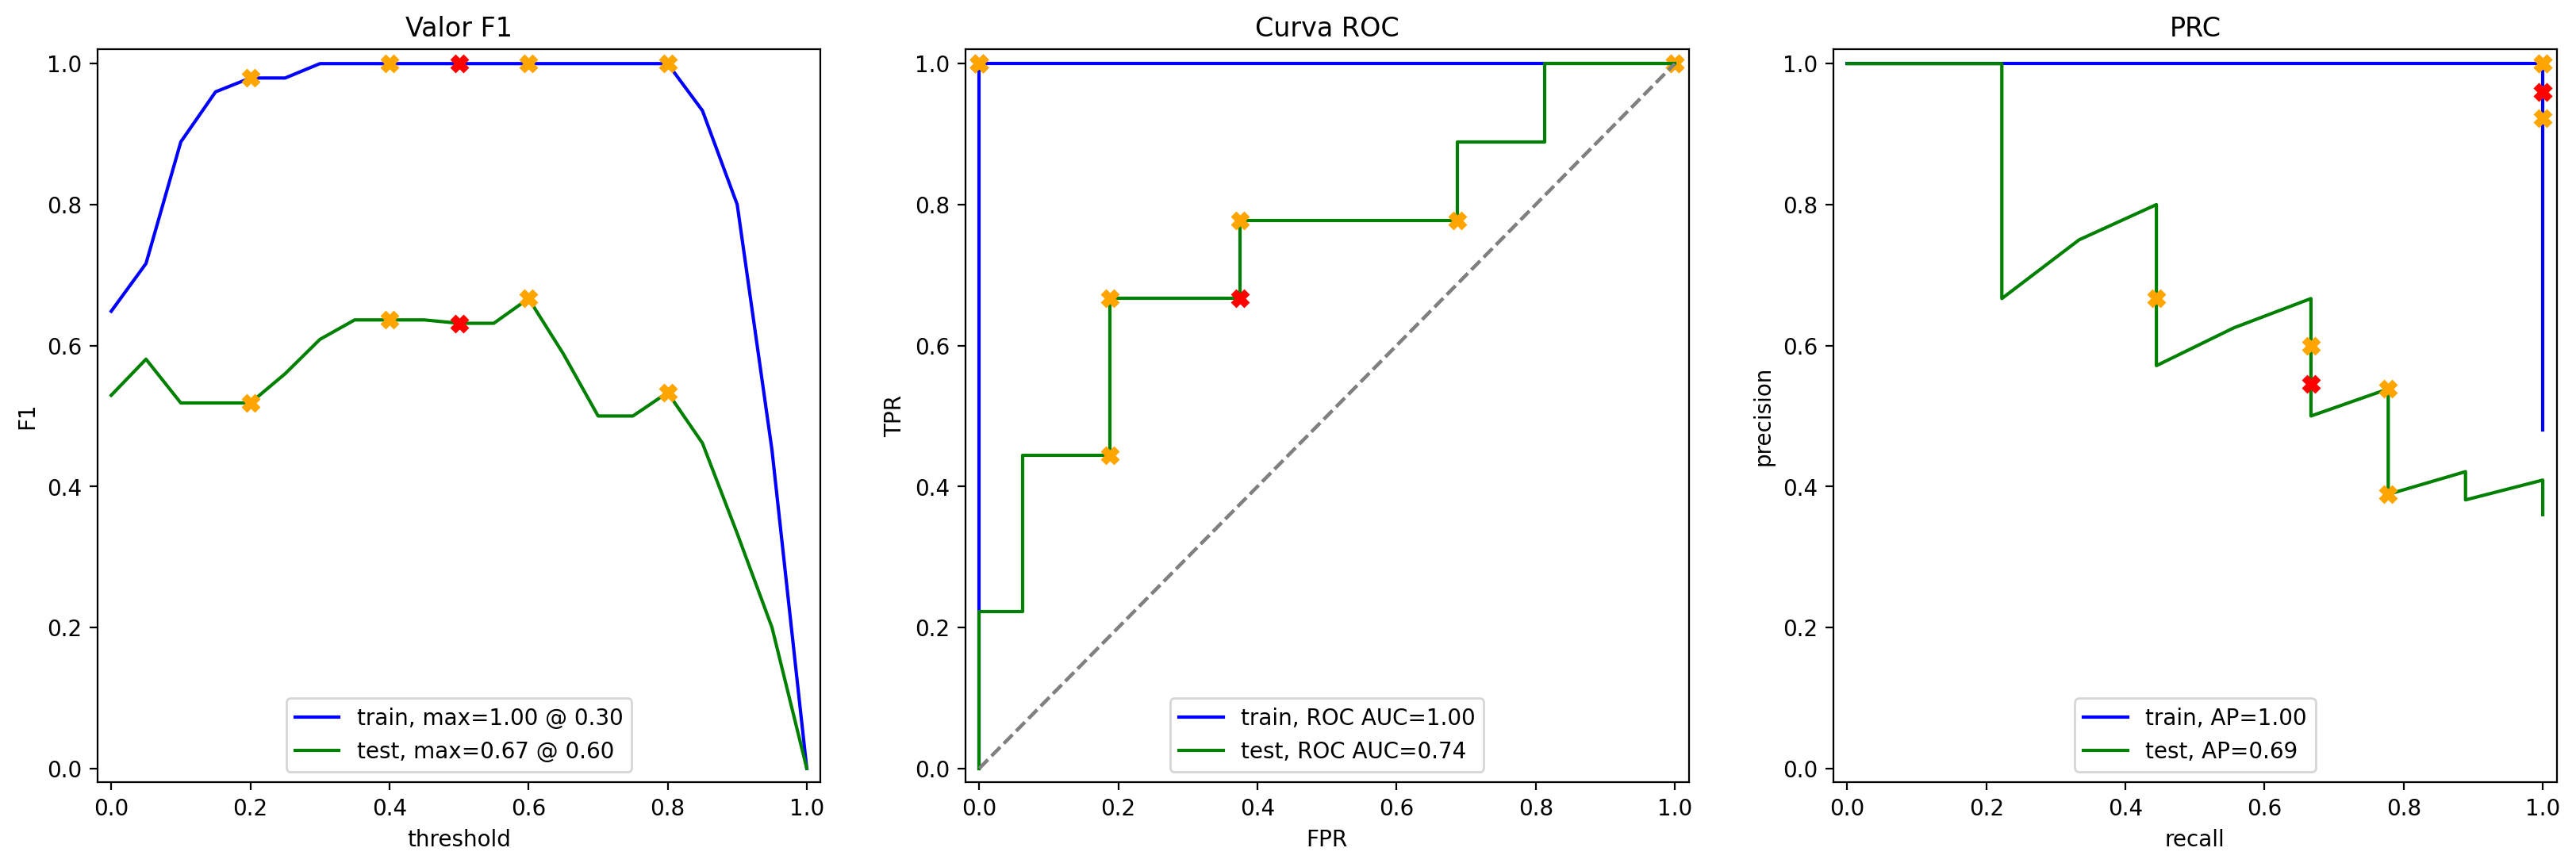

In [38]:

model_final_bert = LogisticRegression(solver='liblinear')
model_final_bert.fit(train_features_4, train_target_4) 

# Avaliar usando a função do projeto
evaluate_model(model_final_bert, train_features_4, train_target_4, test_features_4, test_target_4)

## Minhas Resenhas

In [39]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

my_reviews

,review,review_norm
0,"Eu simplesmente não gostei, não é meu tipo de ...",eu simplesmente n o gostei n o meu tipo de filme
1,"Bem, eu fiquei entediado e dormi no meio do fi...",bem eu fiquei entediado e dormi no meio do filme
2,Eu fiquei realmente fascinado com o filme,eu fiquei realmente fascinado com o filme
3,Os atores pareciam muito velhos e desinteressa...,os atores pareciam muito velhos e desinteressa...
4,Eu não esperava que a nova versão fosse tão bo...,eu n o esperava que a nova vers o fosse t o bo...
5,"O filme tem seus prós e contras, mas eu sinto ...",o filme tem seus pr s e contras mas eu sinto q...
6,Que tentativa podre de comédia. Nem uma única ...,que tentativa podre de com dia nem uma nica pi...
7,Lançar na Netflix foi uma jogada corajosa e eu...,lan ar na netflix foi uma jogada corajosa e eu...


### Modelo 1

In [49]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.52:  eu simplesmente n o gostei n o meu tipo de filme
0.49:  bem eu fiquei entediado e dormi no meio do filme
0.65:  eu fiquei realmente fascinado com o filme
0.52:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.45:  eu n o esperava que a nova vers o fosse t o boa os escritores realmente se importaram com o material
0.49:  o filme tem seus pr s e contras mas eu sinto que em geral um filme decente eu posso me imaginar indo
0.59:  que tentativa podre de com dia nem uma nica piada cai todo mundo age de forma irritante e barulhenta
0.50:  lan ar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir epis dio ap s


### Modelo 2

In [43]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(vectorizer_2.transform(texts.apply(lambda x: text_preprocessing_2(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.50:  eu simplesmente n o gostei n o meu tipo de filme
0.50:  bem eu fiquei entediado e dormi no meio do filme
0.73:  eu fiquei realmente fascinado com o filme
0.53:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.41:  eu n o esperava que a nova vers o fosse t o boa os escritores realmente se importaram com o material
0.49:  o filme tem seus pr s e contras mas eu sinto que em geral um filme decente eu posso me imaginar indo
0.67:  que tentativa podre de com dia nem uma nica piada cai todo mundo age de forma irritante e barulhenta
0.52:  lan ar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir epis dio ap s


### Modelo 3

In [46]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_2(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.63:  eu simplesmente n o gostei n o meu tipo de filme
0.63:  bem eu fiquei entediado e dormi no meio do filme
0.63:  eu fiquei realmente fascinado com o filme
0.63:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.56:  eu n o esperava que a nova vers o fosse t o boa os escritores realmente se importaram com o material
0.63:  o filme tem seus pr s e contras mas eu sinto que em geral um filme decente eu posso me imaginar indo
0.63:  que tentativa podre de com dia nem uma nica piada cai todo mundo age de forma irritante e barulhenta
0.63:  lan ar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir epis dio ap s


### Modelo 4

In [48]:
texts = my_reviews['review_norm']

my_reviews_features_4 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_final_bert.predict_proba(my_reviews_features_4)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.64:  eu simplesmente n o gostei n o meu tipo de filme
0.34:  bem eu fiquei entediado e dormi no meio do filme
0.65:  eu fiquei realmente fascinado com o filme
0.52:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.56:  eu n o esperava que a nova vers o fosse t o boa os escritores realmente se importaram com o material
0.50:  o filme tem seus pr s e contras mas eu sinto que em geral um filme decente eu posso me imaginar indo
0.53:  que tentativa podre de com dia nem uma nica piada cai todo mundo age de forma irritante e barulhenta
0.63:  lan ar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir epis dio ap s


## Conclusões

Ao longo do projeto, foi a analizado 04 modelos, onde a cada modelo, aumentou-se o critério e tecnica de EDA. Inicialmente todos deram partida com os dados Normalizados.
Nota-se: O conjunto de dados estava balanceado, dito isso, foi possível identificar tais analises:

Modelo Dummy: cumpre seu papel de estabelecer o "piso" de performance, provando que qualquer palpite aleatório ou simplista resultará em 50% de acurácia. O valor de 0.50 no ROC AUC confirma que este modelo não possui capacidade de distinção entre resenhas positivas e negativas, servindo como uma régua comparativa essencial: para que os próximos modelos

Modelo 01: [NLTK, TF-IDF e Regressão Logistica], onde foi trabalhado com stopwords (remoção de uma lista de palavras gramaticais que aparecem muito, mas não têm "sentimento" (ex: the, is, at, on, by).) :apresentou um desempenho significativamente superior ao baseline, atingindo 88% de acurácia e 0.95 de ROC AUC no conjunto de teste. Embora apresente um leve indício de sobreajuste (overfitting) — dado que a performance em treino é superior à de teste —, o modelo demonstra uma alta capacidade de distinção entre sentimentos. Este resultado estabelece um patamar elevado para os modelos subsequentes, mostrando que palavras isoladas e suas frequências já carregam grande parte da carga semântica necessária para a classificação deste dataset

Modelo 02: [spaCy, TF-IDF e Regressão Logística], foi introduzido o uso da biblioteca spaCy para lematização, buscando reduzir a variabilidade do vocabulário. Entretanto, os resultados de teste mostraram uma leve oscilação negativa, com a acurácia passando de 88% para 87%, e o ROC AUC mantendo-se estável em 0.95. Essa equivalência sugere que, para este conjunto de dados, o processamento linguístico mais complexo (lematização) não agregou valor preditivo em relação à normalização simples do Modelo 01, indicando que as formas originais das palavras já eram suficientemente informativas para o classificador.

Modelo 03: [SpaCy, TF-IDF e XGBoost], foi utilizado o algoritmo XGBoost, um dos mais poderosos para dados estruturados, mas que apresentou um desempenho inferior aos modelos lineares neste projeto, com 0.84 de acurácia no teste. Esse resultado ilustra um fenômeno comum em Processamento de Linguagem Natural: algoritmos baseados em árvores muitas vezes sofrem para lidar com a alta dimensionalidade e a esparsidade das matrizes TF-IDF. Além disso, o maior distanciamento entre as métricas de treino e teste sugere uma dificuldade maior de generalização em comparação com a Regressão Logística

Modelo 04: [Bert], foi utilizado a arquitetura de ponta BERT, neste caso apresentou um cenário de overfitting severo, evidenciado pela acurácia perfeita (1.0) no treino e uma queda substancial para 0.72 no teste. Este resultado é uma consequência direta da limitação computacional do ambiente (CPU), que exigiu o treinamento com uma amostra irrisória de dados.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Quando analisamos novas frases em "Minhas Resenhas"


Mesmo com o overfitting causado pela amostra pequena, o BERT foi o único capaz de entender nuances contextuais que os outros ignoraram:

Detecção de Negatividade Real: Na frase "eu fiquei entediado e dormi no meio do filme", o BERT deu a menor nota de todos os testes (0.34). Ele entende que "dormi no meio" é um sinal de tédio, enquanto o TF-IDF achava que era algo neutro (0.50).

A "Podre" Comédia: Diferente dos outros modelos que se deixaram enganar pelas palavras "comédia" e "piada" (elevando a nota para 0.67 no Modelo 2), o BERT manteve uma nota de 0.53. Ele ainda está indeciso devido ao pouco treino, mas foi o que menos se "empolgou" com a ironia.

Consistência: Ele identificou corretamente o entusiasmo na frase da Netflix (0.63), mostrando que o pré-treino dele ajuda a compensar a falta de dados.


Em suma, o projeto revela que a inteligência de um modelo de NLP não reside apenas em suas métricas de acurácia de treino, mas em sua capacidade de generalização semântica. O BERT, apesar de exigir mais recursos, prova ser o único capaz de 'ler as entrelinhas', enquanto os modelos clássicos apenas 'contam palavras'

# Checklist

- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [x]  Os modelos são treinados e testados
- [x]  O limiar da métrica foi atingido
- [x]  Todas as células de código estão organizadas na ordem de sua execução
- [x]  Todas as células de código podem ser executadas sem erros
- [x]  Há conclusões 